In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/water_potability.csv')

In [3]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


<Axes: xlabel='Potability', ylabel='count'>

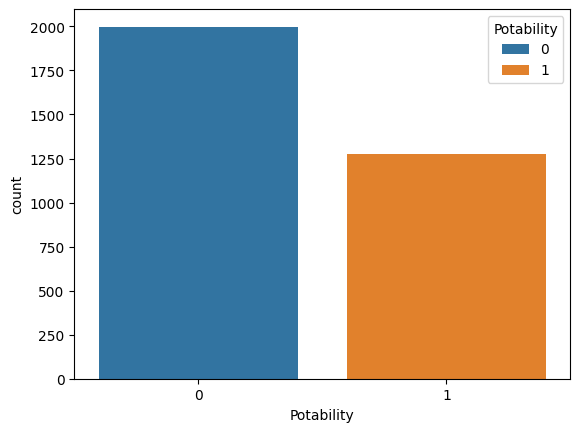

In [5]:
sns.countplot(x='Potability', data=df, hue='Potability')

In [6]:
df['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

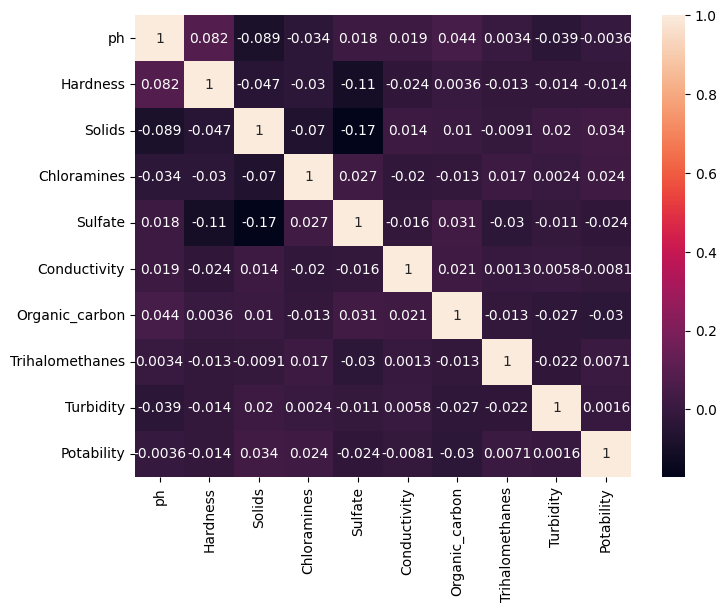

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True);

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.impute import KNNImputer

In [10]:
X = df.drop('Potability', axis=1)
y = df['Potability']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=104, stratify=y)

In [12]:
num_features = X_train.columns.tolist()

In [13]:
num_features

['ph',
 'Hardness',
 'Solids',
 'Chloramines',
 'Sulfate',
 'Conductivity',
 'Organic_carbon',
 'Trihalomethanes',
 'Turbidity']

In [14]:
num_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features)
    ],
    remainder='passthrough'
)

In [16]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler_2', StandardScaler()),
    ('model', LogisticRegressionCV(
        cv=10,
        penalty='l2',
        solver='lbfgs',
        class_weight='balanced',
        Cs=10,
        max_iter=100_000,
        n_jobs=-1,
        random_state=104
    ))
])

In [17]:
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

In [18]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [19]:
y_pred = pipe.predict(X_test)
y_pred_proba = pipe.predict_proba(X_test)[:, 1]
y_train_proba = pipe.predict_proba(X_train)[:, 1]

In [20]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc_train = roc_auc_score(y_train, y_train_proba)
roc_auc_test = roc_auc_score(y_test, y_pred_proba)

In [21]:
best_model = pipe.named_steps['model']
print(f"Лучшее значение C: {best_model.C_}")

Лучшее значение C: [0.0001]


In [22]:
accuracy

0.6646341463414634

In [23]:
precision

0.5737704918032787

In [24]:
recall

0.546875

In [25]:
roc_auc_train

0.6954640421724622

In [26]:
roc_auc_test

0.71875

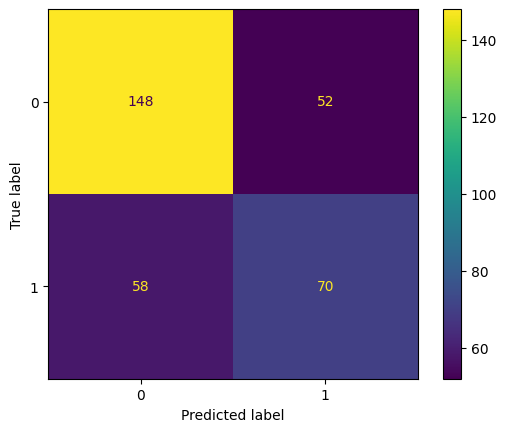

In [27]:
ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test);

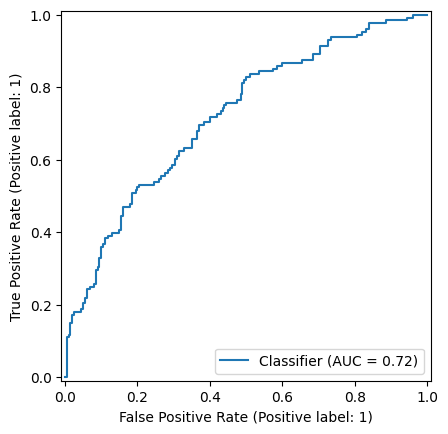

In [28]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

In [29]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [30]:
y_full_proba = pipe.predict_proba(X)[:, 1]

In [47]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение C: {best_final_model.C_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение C: [0.0001]
Лучшее значение l1_ratio: [None]


In [32]:
roc_auc_full = roc_auc_score(y, y_full_proba)

In [33]:
roc_auc_full

0.6983587656514103

In [34]:
df[df['Potability'] == 1].head(5)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
250,9.445130,145.805402,13168.529156,9.444471,310.583374,592.659021,8.606397,77.577460,3.875165,1
251,9.024845,128.096691,19859.676476,8.016423,300.150377,451.143481,14.770863,73.778026,3.985251,1
252,NaN,169.974849,23403.637304,8.519730,NaN,475.573562,12.924107,50.861913,2.747313,1
253,6.800119,242.008082,39143.403329,9.501695,187.170714,376.456593,11.432466,73.777275,3.854940,1
254,7.174135,203.408935,20401.102461,7.681806,287.085679,315.549900,14.533510,74.405616,3.939896,1


In [35]:
df[df['Potability'] == 0].head(5)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [36]:
test_df = pd.DataFrame([
    {
        'ph': 9.445130,
        'Hardness': 145.805402,
        'Solids': 13168.529156,
        'Chloramines': 9.444471,
        'Sulfate': 310.583374,
        'Conductivity': 592.659021,
        'Organic_carbon': 8.606397,
        'Trihalomethanes': 77.577460,
        'Turbidity': 3.875165
    },
    {
        'ph': 8.316766,
        'Hardness': 214.373394,
        'Solids': 22018.417441,
        'Chloramines': 8.059332,
        'Sulfate': 356.886136,
        'Conductivity': 363.266516,
        'Organic_carbon': 18.436524,
        'Trihalomethanes': 100.341674,
        'Turbidity': 4.628771
    }
])

In [37]:
test_df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,9.445130,145.805402,13168.529156,9.444471,310.583374,592.659021,8.606397,77.577460,3.875165
1,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771


In [38]:
probabilities = pipe.predict_proba(test_df)[:, 1]
predictions = pipe.predict(test_df)

In [39]:
print(f"--- Проба №1 (Родник) -> Вероятность пригодности для питья: {probabilities[0]:.2%}")
print(f"    Вердикт модели: Можно ли пить эту воду? -> {'ДА' if predictions[0] == 1 else 'НЕТ'}")

print(f"--- Проба №2 (Хим-коктейль) -> Вероятность пригодности для питья: {probabilities[1]:.2%}")
print(f"    Вердикт модели: Можно ли пить эту воду? -> {'ДА' if predictions[1] == 1 else 'НЕТ'}")

--- Проба №1 (Родник) -> Вероятность пригодности для питья: 52.03%
    Вердикт модели: Можно ли пить эту воду? -> ДА
--- Проба №2 (Хим-коктейль) -> Вероятность пригодности для питья: 49.12%
    Вердикт модели: Можно ли пить эту воду? -> НЕТ


In [40]:
class_percents = df['Potability'].value_counts(normalize=True) * 100

baseline_string = f"0: {class_percents[0]:.1f}%, 1: {class_percents[1]:.1f}%"
print(f"{baseline_string}")

0: 61.0%, 1: 39.0%


In [41]:
import json
import os

advanced_report = {
    "project": "Water Potability Prediction",
    "model": "LogisticRegressionCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "cv": best_model.cv,
        "penalty": best_model.penalty,
        "solver":best_model.solver,
        "C": best_model.C_.tolist()[0],
    },
    "final_parameters": {
        "cv": best_final_model.cv,
        "penalty": best_final_model.penalty,
        "solver":best_final_model.solver,
        "C": best_final_model.C_.tolist()[0],
    },
    "metrics": {
        "Accuracy Score": accuracy,
        "Precision Score": precision,
        "Recall": recall,
        "ROC AUC Score Train": roc_auc_train,
        "ROC AUC Score Test": roc_auc_test,
        "ROC AUC Score Full": roc_auc_full,
        "Class Balance": baseline_string
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [42]:
from joblib import dump, load

In [43]:
dump(pipe, "model/water_potability_predict_logistic_regression_cv_2026_v1.pkl")

['model/water_potability_predict_logistic_regression_cv_2026_v1.pkl']

In [44]:
loaded_pipe = load("model/water_potability_predict_logistic_regression_cv_2026_v1.pkl")

In [45]:
loaded_pipe.predict(test_df)

array([1, 0])

In [46]:
loaded_pipe.predict_proba(test_df)[:, 1]

array([0.5203189 , 0.49117716])